# NBA Free Throw Analysis: 2018-19 Season

## Executive Summary
This analysis explores free throw shooting patterns in the NBA's 2018-19 season using play-by-play data. We investigate several key questions:

## Research Questions
1. **Sequential Performance**: Are players more likely to make the 2nd free throw?
2. **Home Court Advantage**: Do players shoot better at home vs. away games?
3. **Arena Effects**: Are certain arenas more difficult for visiting teams?
4. **Game Context**: Does score differential or time remaining affect FT accuracy?
5. **Player Consistency**: Who are the most consistent free throw shooters?

## Dataset
- **Source**: NBA play-by-play data from the 2018-19 season (Kaggle)
- **Games**: 1311 unique games

## 1. Data Loading and Preparation
First, load the play-by-play data and explore its structure

In [72]:
import pandas as pd

file_path = 'NBA_PBP_2018-19.csv'
pbp_df = pd.read_csv(file_path)

print(pbp_df.head())

                            URL GameType                        Location  \
0  /boxscores/201810160BOS.html  regular  TD Garden Boston Massachusetts   
1  /boxscores/201810160BOS.html  regular  TD Garden Boston Massachusetts   
2  /boxscores/201810160BOS.html  regular  TD Garden Boston Massachusetts   
3  /boxscores/201810160BOS.html  regular  TD Garden Boston Massachusetts   
4  /boxscores/201810160BOS.html  regular  TD Garden Boston Massachusetts   

              Date     Time WinningTeam  Quarter  SecLeft AwayTeam  \
0  October 16 2018  8:00 PM         BOS        1      720      PHI   
1  October 16 2018  8:00 PM         BOS        1      700      PHI   
2  October 16 2018  8:00 PM         BOS        1      700      PHI   
3  October 16 2018  8:00 PM         BOS        1      675      PHI   
4  October 16 2018  8:00 PM         BOS        1      673      PHI   

                                            AwayPlay  ...  FreeThrowNum  \
0  Jump ball: J. Embiid vs. A. Horford (B. Simm

In [73]:
# Only include rows with free throw data

pbp_df_filtered = pbp_df.dropna(subset=['FreeThrowShooter', 'FreeThrowOutcome', 'FreeThrowNum'])
print(pbp_df_filtered.head())

                             URL GameType                        Location  \
52  /boxscores/201810160BOS.html  regular  TD Garden Boston Massachusetts   
53  /boxscores/201810160BOS.html  regular  TD Garden Boston Massachusetts   
65  /boxscores/201810160BOS.html  regular  TD Garden Boston Massachusetts   
67  /boxscores/201810160BOS.html  regular  TD Garden Boston Massachusetts   
76  /boxscores/201810160BOS.html  regular  TD Garden Boston Massachusetts   

               Date     Time WinningTeam  Quarter  SecLeft AwayTeam  \
52  October 16 2018  8:00 PM         BOS        1      394      PHI   
53  October 16 2018  8:00 PM         BOS        1      394      PHI   
65  October 16 2018  8:00 PM         BOS        1      313      PHI   
67  October 16 2018  8:00 PM         BOS        1      313      PHI   
76  October 16 2018  8:00 PM         BOS        1      267      PHI   

                               AwayPlay  ...  FreeThrowNum EnterGame  \
52                                  Na

In [74]:
# Check for any null values (many will be null since we are only focusing on free throws)

print(pbp_df_filtered.isnull().sum())

URL                       0
GameType                  0
Location                  0
Date                      0
Time                      0
WinningTeam               0
Quarter                   0
SecLeft                   0
AwayTeam                  0
AwayPlay              30828
AwayScore                 0
HomeTeam                  0
HomePlay              29923
HomeScore                 0
Shooter               60751
ShotType              60751
ShotOutcome           60751
ShotDist              60751
Assister              60751
Blocker               60751
FoulType              60751
Fouler                60751
Fouled                60751
Rebounder             60751
ReboundType           60751
ViolationPlayer       60751
ViolationType         60751
TimeoutTeam           60751
FreeThrowShooter          0
FreeThrowOutcome          0
FreeThrowNum              0
EnterGame             60751
LeaveGame             60751
TurnoverPlayer        60751
TurnoverType          60751
TurnoverCause       

In [75]:
print(pbp_df_filtered.describe(include='all'))

                                 URL GameType  \
count                          60751    60751   
unique                          1311        2   
top     /boxscores/201811030PHI.html  regular   
freq                              92    56757   
mean                             NaN      NaN   
std                              NaN      NaN   
min                              NaN      NaN   
25%                              NaN      NaN   
50%                              NaN      NaN   
75%                              NaN      NaN   
max                              NaN      NaN   

                                     Location              Date     Time  \
count                                   60751             60751    60751   
unique                                     31               212       20   
top     STAPLES Center Los Angeles California  November 23 2018  8:00 PM   
freq                                     4265               618    13999   
mean                           

### Filter to Relevant Columns
Focus on the columns necessary for the free throw analysis

In [76]:
df = pbp_df_filtered[['URL', 'Date', 'GameType', 'Quarter', 'SecLeft', 
         'AwayTeam', 'AwayScore', 'HomeTeam', 'HomeScore', 'WinningTeam',
         'FreeThrowShooter', 'FreeThrowOutcome', 'FreeThrowNum']]

In [77]:
df['FreeThrowOutcome'].value_counts()  # made vs missed

FreeThrowOutcome
make    46626
miss    14125
Name: count, dtype: int64

## 2. Sequential FT Analysis
**Question**: Are players more likely to make their 2nd free throw compared to their 1st?

In [78]:
ft_sequence_analysis = df.groupby('FreeThrowNum')['FreeThrowOutcome'].apply(
    lambda x: (x == 'make').mean() 
)

ft_sequence_analysis

FreeThrowNum
1 of 1       0.746778
1 of 2       0.737091
1 of 3       0.801758
2 of 2       0.790397
2 of 3       0.875977
3 of 3       0.864258
technical    0.817262
Name: FreeThrowOutcome, dtype: float64

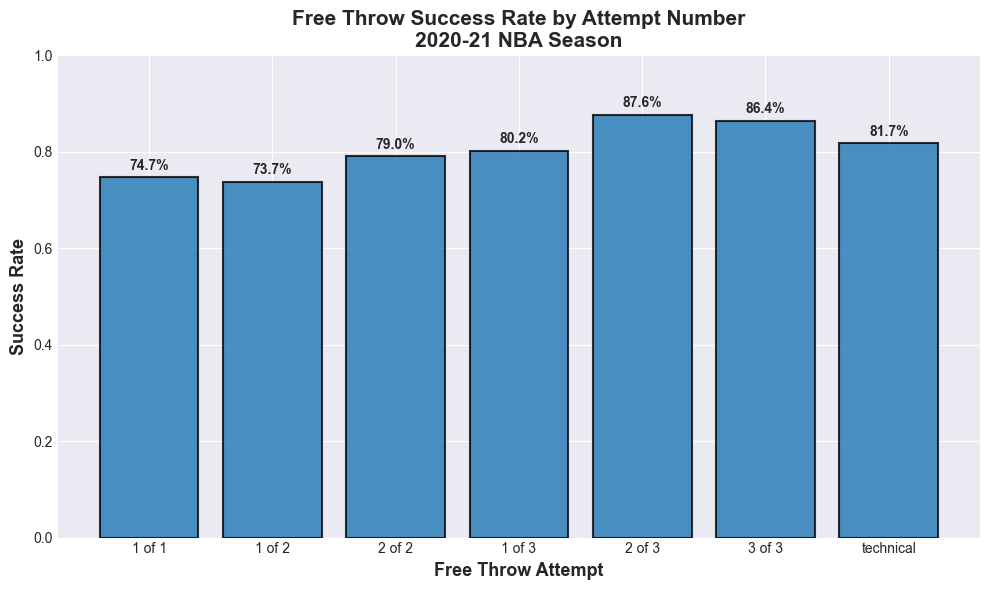

In [79]:
import matplotlib.pyplot as plt
import numpy as np

# Define order
ft_order = ['1 of 1', '1 of 2', '2 of 2', '1 of 3', '2 of 3', '3 of 3', 'technical']

ft_sequence_analysis = ft_sequence_analysis.reindex([x for x in ft_order if x in ft_sequence_analysis.index])

# Create bar chart
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(range(len(ft_sequence_analysis)), ft_sequence_analysis.values, alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels
for i, val in enumerate(ft_sequence_analysis.values):
    ax.text(i, val + 0.01, f'{val:.1%}', ha='center', va='bottom', fontweight='bold')

ax.set_xlabel('Free Throw Attempt', fontsize=13, fontweight='bold')
ax.set_ylabel('Success Rate', fontsize=13, fontweight='bold')
ax.set_title('Free Throw Success Rate by Attempt Number\n2020-21 NBA Season', fontsize=15, fontweight='bold')
ax.set_xticks(range(len(ft_sequence_analysis)))
ax.set_xticklabels(ft_sequence_analysis.index)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

### Key Finding
Players show a progressive improvement in FT accuracy:
- **1 of 2**: 73.7% -> **2 of 2**: 79.0% (+5.3%)
- **1 of 3**: 80.2% -> **2 of 3**: 87.6% (+7.4%) -> **3 of 3**: 86.4%

This suggests a "warm-up" effect or increased focus on subsequent attempts.

## 3. Home Court Advantage
**Question**: Do players shoot better free throws at home versus away?

In [80]:
# Add AwayPlay and HomePlay columns back to identify home/away
pbp_df = pd.read_csv(file_path)
df_full = pbp_df[['URL', 'Date', 'GameType', 'Quarter', 'SecLeft', 'Location',
                  'AwayTeam', 'AwayScore', 'AwayPlay', 'HomeTeam', 'HomeScore', 'HomePlay',
                  'FreeThrowShooter', 'FreeThrowOutcome', 'FreeThrowNum']].dropna(
    subset=['FreeThrowShooter', 'FreeThrowOutcome', 'FreeThrowNum'])

# Create home/away indicator
df_full['FT_HomeAway'] = df_full.apply(
    lambda row: 'Home' if pd.notna(row['HomePlay']) else ('Away' if pd.notna(row['AwayPlay']) else None),
    axis=1
)

# Calculate success rates
home_away_analysis = df_full.groupby('FT_HomeAway')['FreeThrowOutcome'].apply(
    lambda x: (x == 'make').mean()
)

print(home_away_analysis)

FT_HomeAway
Away    0.766868
Home    0.768100
Name: FreeThrowOutcome, dtype: float64


### Key Finding
There is no meaningful home court advantage for free throw shooting. Home teams shoot 76.7% while away teams shoot 76.8%

This suggests free throw shooting is likely immune to crowd distractions

## 4. Arena Effects
**Question**: Are certain NBA arenas more difficult for visiting teams to shoot free throws?

We'll analyze only away team FT performance to control for player skill differences.

In [81]:
# Filter to away teams only and calculate stats by arena
away_ft = df_full[df_full['FT_HomeAway'] == 'Away']

# Calculate counts first to filter by sample size
ft_counts = away_ft.groupby('Location').size()
arenas_with_enough_data = ft_counts[ft_counts >= 80].index  # Minimum 80 attempts

# Filter and calculate success rate
away_ft_filtered = away_ft[away_ft['Location'].isin(arenas_with_enough_data)]
ft_by_arena = away_ft_filtered.groupby('Location')['FreeThrowOutcome'].apply(lambda x: (x == 'make').mean())
ft_by_arena_sorted = ft_by_arena.sort_values(ascending=False)

ft_by_arena_sorted

Location
Oracle Arena Oakland California                      0.802896
FedEx Forum Memphis Tennessee                        0.793750
Moda Center Portland Oregon                          0.789762
Madison Square Garden (IV) New York New York         0.789366
STAPLES Center Los Angeles California                0.784675
American Airlines Center Dallas Texas                0.776119
Capital One Arena Washington District of Columbia    0.775843
Vivint Smart Home Arena Salt Lake City Utah          0.774359
Spectrum Center Charlotte North Carolina             0.773756
Toyota Center Houston Texas                          0.773516
Scotiabank Arena Toronto Canada                      0.773355
Barclays Center Brooklyn New York                    0.773176
Quicken Loans Arena Cleveland Ohio                   0.771930
AmericanAirlines Arena Miami Florida                 0.771637
Amway Center Orlando Florida                         0.771567
Smoothie King Center New Orleans Louisiana           0.769723

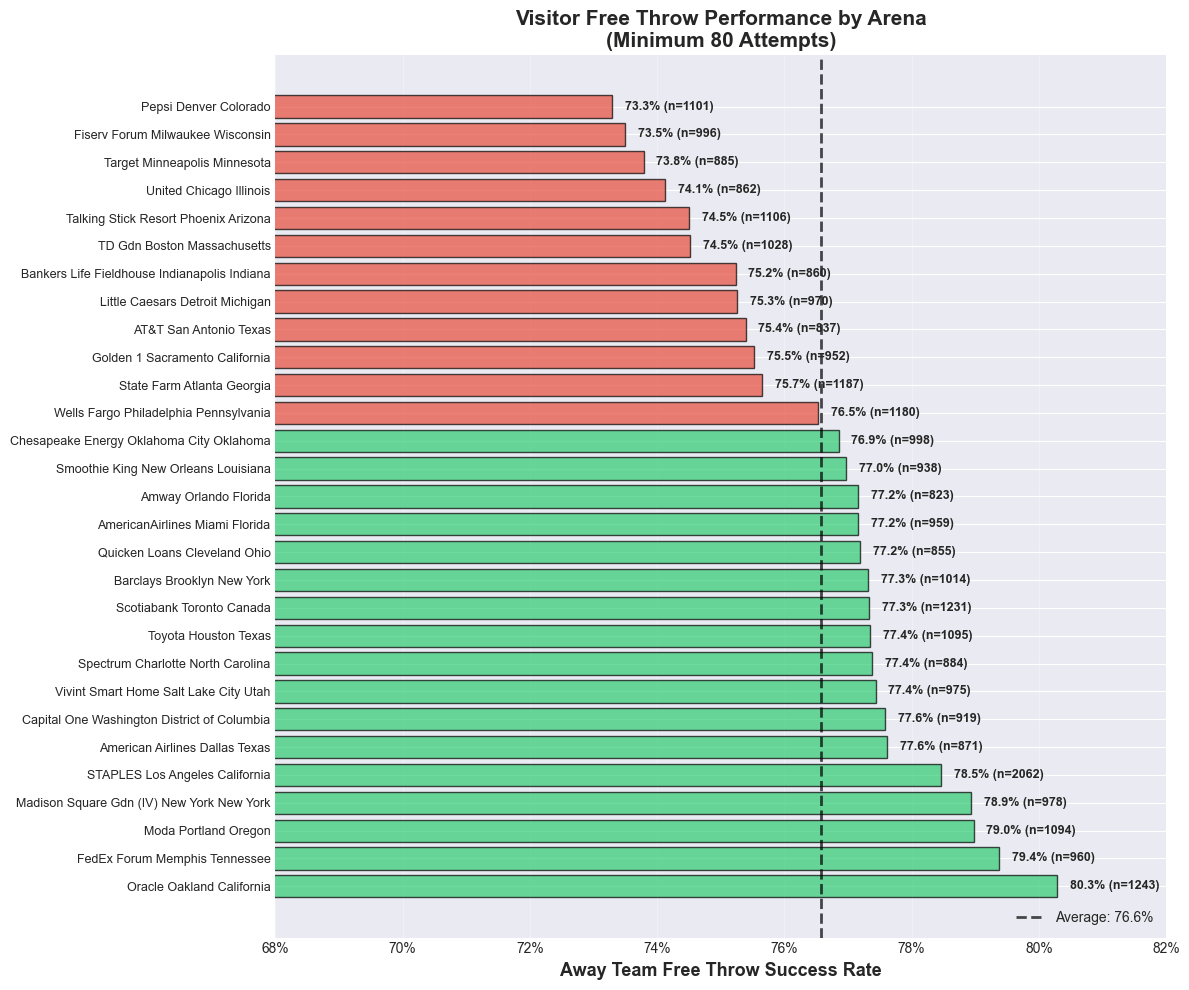

In [82]:
# Create horizontal bar chart
fig, ax = plt.subplots(figsize=(12, 10))

# Color code: green for above average, red for below
avg_ft_pct = ft_by_arena_sorted.mean()
colors_arena = ['#2ecc71' if x >= avg_ft_pct else '#e74c3c' for x in ft_by_arena_sorted.values]

ax.barh(range(len(ft_by_arena_sorted)), ft_by_arena_sorted.values, 
        color=colors_arena, alpha=0.7, edgecolor='black')

# Add value labels
for i, (arena, val) in enumerate(ft_by_arena_sorted.items()):
    ax.text(val + 0.002, i, f'{val:.1%} (n={ft_counts[arena]})', 
            va='center', fontweight='bold', fontsize=9)

# Add average line
ax.axvline(avg_ft_pct, color='black', linestyle='--', linewidth=2, 
           label=f'Average: {avg_ft_pct:.1%}', alpha=0.7)

# Shorten arena names
arena_labels = [a.replace(' Center', '').replace(' Arena', '').replace(' Garden', ' Gdn') 
                for a in ft_by_arena_sorted.index]

ax.set_yticks(range(len(ft_by_arena_sorted)))
ax.set_yticklabels(arena_labels, fontsize=9)
ax.set_xlabel('Away Team Free Throw Success Rate', fontsize=13, fontweight='bold')
ax.set_title('Visitor Free Throw Performance by Arena\n(Minimum 80 Attempts)', 
             fontsize=15, fontweight='bold')
ax.set_xlim(0.68, 0.82)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### Key Finding
Free throw performance varies across NBA arenas, with a **7% spread** between the best and worst venues.

**Top Performance Arena**: Oakland Arena (Golden State Warriors) - Highest FT%  
**Most Challenging Arena**: Pepsi Center Denver, Colorado (Nuggets) - Lowest FT%


## 5. Game Context Analysis
**Question**: How do situational factors (score differential, time remaining, quarter) affect FT performance?

In [83]:
# Create derived features
df_full['ScoreDiff'] = abs(df_full['HomeScore'] - df_full['AwayScore'])
df_full['IsClutch'] = df_full['SecLeft'] <= 120  # Last 2 minutes
df_full['GameSituation'] = pd.cut(df_full['ScoreDiff'], 
                                   bins=[-1, 5, 15, 100], 
                                   labels=['Close (0-5)', 'Competitive (6-15)', 'Blowout (16+)'])

# Analyze by quarter
ft_by_quarter = df_full.groupby('Quarter')['FreeThrowOutcome'].apply(lambda x: (x == 'make').mean())

# Analyze by game situation
ft_by_situation = df_full.groupby('GameSituation')['FreeThrowOutcome'].apply(lambda x: (x == 'make').mean())

# Analyze clutch vs non-clutch
ft_by_clutch = df_full.groupby('IsClutch')['FreeThrowOutcome'].apply(lambda x: (x == 'make').mean())

print("FT% by Quarter:")
print(ft_by_quarter)
print("\nFT% by Game Situation:")
print(ft_by_situation)
print(f"\nClutch Time (last 2 min): {ft_by_clutch[True]:.1%}")
print(f"Non-Clutch: {ft_by_clutch[False]:.1%}")

FT% by Quarter:
Quarter
1    0.771701
2    0.776374
3    0.768966
4    0.755561
5    0.751807
6    0.815789
7    0.782609
8    0.666667
Name: FreeThrowOutcome, dtype: float64

FT% by Game Situation:
GameSituation
Close (0-5)           0.768146
Competitive (6-15)    0.769234
Blowout (16+)         0.761486
Name: FreeThrowOutcome, dtype: float64

Clutch Time (last 2 min): 76.8%
Non-Clutch: 76.7%


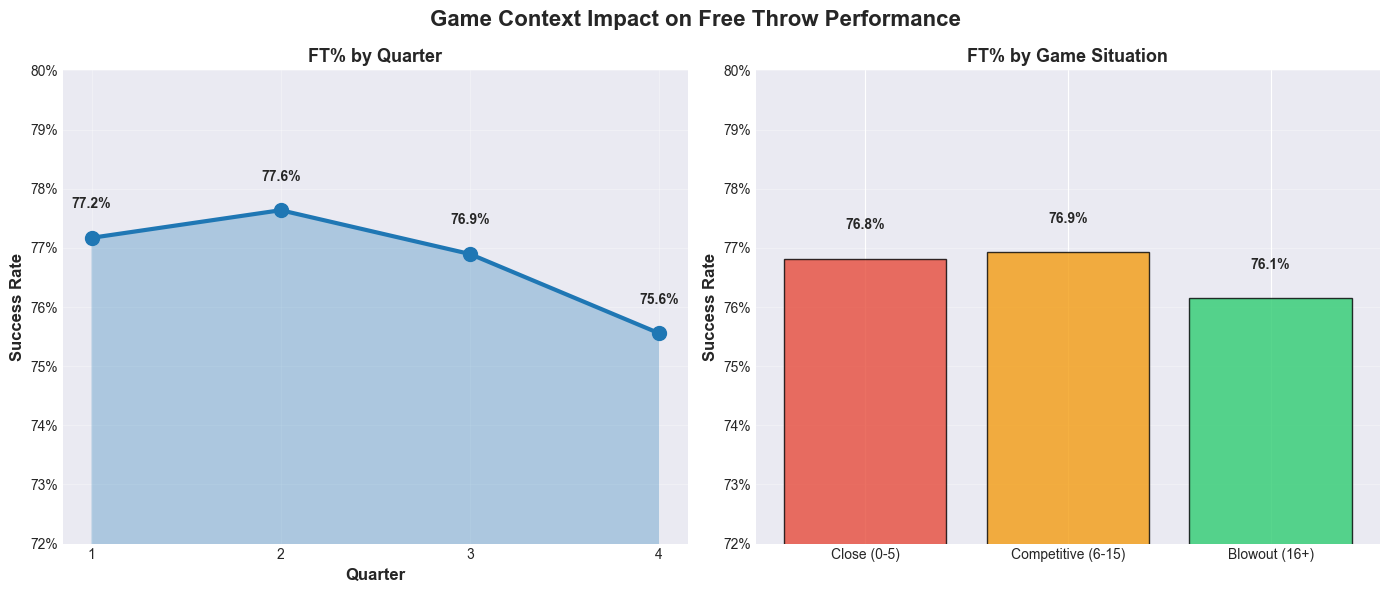

In [84]:
# Create multi-panel visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: FT% by Quarter (Line plot)
quarters = [q for q in ft_by_quarter.index if q <= 4]
ft_by_q = ft_by_quarter[ft_by_quarter.index.isin(quarters)]
ax1.plot(ft_by_q.index, ft_by_q.values, marker='o', linewidth=3, markersize=10)
ax1.fill_between(ft_by_q.index, ft_by_q.values, alpha=0.3)

for i, val in enumerate(ft_by_q.values):
    ax1.text(ft_by_q.index[i], val + 0.005, f'{val:.1%}', ha='center', fontweight='bold')

ax1.set_xlabel('Quarter', fontsize=12, fontweight='bold')
ax1.set_ylabel('Success Rate', fontsize=12, fontweight='bold')
ax1.set_title('FT% by Quarter', fontsize=13, fontweight='bold')
ax1.set_xticks(quarters)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax1.grid(alpha=0.3)
ax1.set_ylim(0.72, 0.8)

# Panel 2: Close Game vs Blowout
colors_sit = ['#e74c3c', '#f39c12', '#2ecc71']
ax2.bar(range(len(ft_by_situation)), ft_by_situation.values, 
        color=colors_sit, alpha=0.8, edgecolor='black')

for i, val in enumerate(ft_by_situation.values):
    ax2.text(i, val + 0.005, f'{val:.1%}', ha='center', fontweight='bold')

ax2.set_xticks(range(len(ft_by_situation)))
ax2.set_xticklabels(ft_by_situation.index)
ax2.set_ylabel('Success Rate', fontsize=12, fontweight='bold')
ax2.set_title('FT% by Game Situation', fontsize=13, fontweight='bold')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0.72, 0.8)

fig.suptitle('Game Context Impact on Free Throw Performance', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Key Finding
Game context has minimal impact on free throw performance

**By Quarter:**
- Q1-Q3: Relatively stable (76.9%-77.6%)
- Q4: Slight decline to 75.6% (late game pressure?)

**By Game Situation:**
- <1% across all situations

## 6. Player Performance
**Question**: Who are the top free throw shooters and most consistent performers?

In [85]:
# Analyze player performance (minimum 50 attempts)
player_stats = df_full.groupby('FreeThrowShooter').agg({
    'FreeThrowOutcome': [
        ('FT_Pct', lambda x: (x == 'make').mean()),
        ('Attempts', 'count'),
        ('Makes', lambda x: (x == 'make').sum())
    ]
}).reset_index()
player_stats.columns = ['Player', 'FT_Pct', 'Attempts', 'Makes']

# Filter for players with 50+ attempts
qualified_players = player_stats[player_stats['Attempts'] >= 50].sort_values('FT_Pct', ascending=False)

print(f"Qualified players (50+ attempts): {len(qualified_players)}\n")
print("Top 10 Free Throw Shooters:")
print(qualified_players.head(10).to_string(index=False))
print("\n\nBottom 10 Free Throw Shooters:")
print(qualified_players.tail(10).to_string(index=False))

Qualified players (50+ attempts): 314

Top 10 Free Throw Shooters:
                  Player   FT_Pct  Attempts  Makes
    S. Curry - curryst01 0.924658       438    405
  M. Brogdon - brogdma01 0.907975       163    148
      K. Love - loveke01 0.903509       114    103
M. Belinelli - belinma01 0.900000       130    117
D. Gallinari - gallida01 0.899772       439    395
  D. Lillard - lillada01 0.897927       627    563
  J. Holiday - holidju01 0.896226       106     95
  Y. Ferrell - ferreyo01 0.895522        67     60
   J. Redick - redicjj01 0.890909       275    245
 N. Stauskas - stausni01 0.890625        64     57


Bottom 10 Free Throw Shooters:
                     Player   FT_Pct  Attempts  Makes
    K. Anderson - anderky01 0.578125        64     37
     M. Plumlee - plumlma01 0.561947       226    127
W. Cauley-Stein - caulewi01 0.551181       254    140
      J. Poeltl - poeltja01 0.534653       101     54
      A. Rivers - riverau01 0.534653       101     54
    A. McKinnie